# Real-Time IT Stock Analysis using RNN (AI/ML)




## Step 1: Install & Import Libraries

`yfinance` gives free historical + near real-time stock data (no API key needed).
We use TensorFlow/Keras for the RNN and LSTM models.


In [23]:
# Run this first in Colab
!pip install yfinance --quiet


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")


Libraries loaded successfully


## Step 2: Collect Historical Stock Data

I'll pull **5 years of historical daily data** for major Indian IT stocks using their NSE ticker symbols (`.NS` suffix).

This IS my historical data — no manual CSV needed. `yfinance` fetches it live from Yahoo Finance, and the same function can be re-run daily to get the latest data, which is what makes this "real-time capable."


In [25]:
# Indian IT sector stocks (NSE tickers)
IT_STOCKS = {
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "Wipro": "WIPRO.NS",
    "HCLTech": "HCLTECH.NS",
    "TechMahindra": "TECHM.NS"
}

# Pick the stock you want to focus on for the model (you can loop over all later)
TICKER_NAME = "Infosys"
TICKER = IT_STOCKS[TICKER_NAME]

# Download 5 years of historical daily data
df = yf.download(TICKER, period="5y", interval="1d")
df = df[["Close"]].dropna()   # We'll predict the Closing price
df.reset_index(inplace=True)

print(f"Data shape: {df.shape}")
df.tail()


[*********************100%***********************]  1 of 1 completed

Data shape: (1240, 2)


Price,Date,Close
Ticker,,INFY.NS
1235,2026-09-04,1130.0
1236,2026-09-07,1087.5
1237,2026-09-08,1082.0
1238,2026-09-09,1035.0
1239,2026-09-10,1036.5


## Step 3: Exploratory Data Analysis (EDA)



Missing values:
 Price  Ticker 
Date              0
Close  INFY.NS    0
dtype: int64

Basic statistics:
 Ticker      INFY.NS
count   1240.000000
mean    1429.930714
std      192.991876
min      985.299988
25%     1298.738129
50%     1416.782959
75%     1546.144196
max     1901.082886


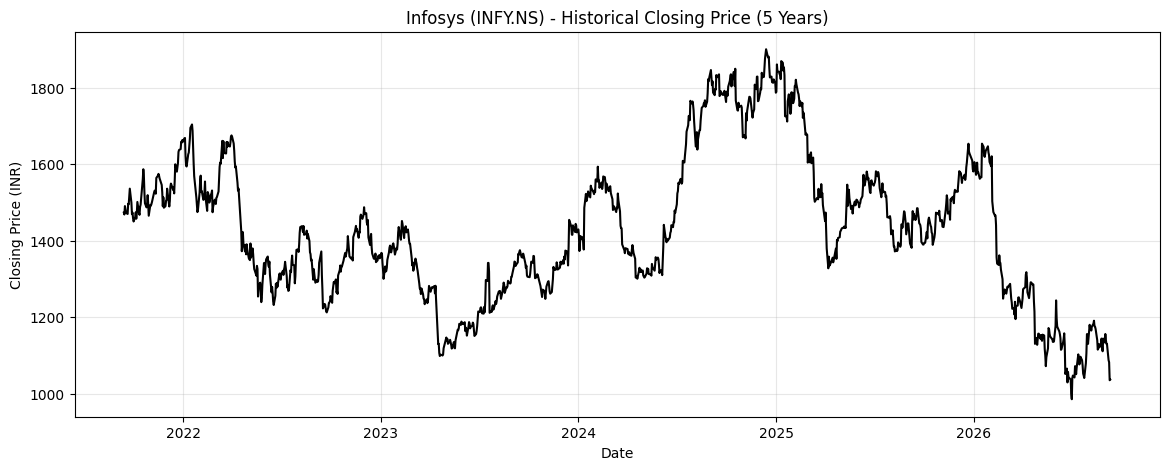

In [26]:
print("Missing values:\n", df.isnull().sum())
print("\nBasic statistics:\n", df["Close"].describe())

plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], color="black")
plt.title(f"{TICKER_NAME} ({TICKER}) - Historical Closing Price (5 Years)")
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid(alpha=0.3)
plt.show()


## Step 4: Data Preprocessing

RNNs need data reshaped into **sequences**: given the last `N` days of closing prices, predict the next day's price.

Steps:
1. Scale the data between 0 and 1 (`MinMaxScaler`) — neural networks train much better on normalized data.
2. Create sliding-window sequences: e.g., use the last 60 days to predict day 61.


In [27]:
# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[["Close"]])

# Create sequences: use last WINDOW_SIZE days to predict the next day
WINDOW_SIZE = 60

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Reshape for RNN input: [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1180, 60, 1)
y shape: (1180,)


## Step 5: Time-Based Train/Test Split


In [28]:
split_ratio = 0.85
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train samples: 1003, Test samples: 177


## Step 6: Build & Train a Simple RNN Model

I start with a basic RNN architecture:
- `SimpleRNN` layers to learn sequential patterns
- `Dropout` to prevent overfitting
- `Dense(1)` output layer to predict a single value (next closing price)

`EarlyStopping` stops training automatically once the model stops improving — this avoids overfitting and saves time.


In [29]:
rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    SimpleRNN(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

rnn_model.compile(optimizer="adam", loss="mean_squared_error")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.1586 - val_loss: 0.0033
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0351 - val_loss: 0.0019
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0225 - val_loss: 0.0015
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0180 - val_loss: 0.0017
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0158 - val_loss: 0.0015
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0134 - val_loss: 0.0013
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0102 - val_loss: 0.0017
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0093 - val_loss: 0.0013
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0088 - val_loss: 0.0018
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0070 - val_loss: 0.0013
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0082 - val_loss: 0.0016
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0

## Step 7: Build & Train an LSTM Model (Comparison)

Plain RNNs struggle with long sequences (vanishing gradient problem). **LSTM** (Long Short-Term Memory) handles long-term dependencies much better.

I build an LSTM with the same structure so the comparison is fair.


In [30]:
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0510 - val_loss: 0.0040
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0097 - val_loss: 0.0030
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0069 - val_loss: 0.0028
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0067 - val_loss: 0.0031
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0063 - val_loss: 0.0022


## Step 8: Evaluate Using RMSE/MAE + Baseline Comparison

This is a **regression problem** (predicting a continuous price), so i use:
- **RMSE** (Root Mean Squared Error) — penalizes large errors more
- **MAE** (Mean Absolute Error) — average absolute prediction error



In [31]:
def evaluate_model(model, X_test, y_test, scaler, name="Model"):
    predictions = model.predict(X_test)

    # Inverse-transform back to actual price scale
    predictions_actual = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
    mae = mean_absolute_error(y_test_actual, predictions_actual)

    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

    return predictions_actual, y_test_actual, rmse, mae

rnn_preds, y_test_actual, rnn_rmse, rnn_mae = evaluate_model(rnn_model, X_test, y_test, scaler, "Simple RNN")
lstm_preds, _, lstm_rmse, lstm_mae = evaluate_model(lstm_model, X_test, y_test, scaler, "LSTM")

# Baseline: naive forecast (today's price predicts tomorrow's price)
baseline_preds = scaler.inverse_transform(scaled_data[split_index+WINDOW_SIZE-1:-1])
baseline_rmse = np.sqrt(mean_squared_error(y_test_actual, baseline_preds))
baseline_mae = mean_absolute_error(y_test_actual, baseline_preds)
print(f"--- Naive Baseline (Today = Tomorrow) ---")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"MAE:  {baseline_mae:.2f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
--- Simple RNN ---
RMSE: 47.20
MAE:  36.61

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
--- LSTM ---
RMSE: 118.24
MAE:  101.22

--- Naive Baseline (Today = Tomorrow) ---
RMSE: 25.70
MAE:  18.23


In [32]:
comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Naive Baseline"],
    "RMSE": [rnn_rmse, lstm_rmse, baseline_rmse],
    "MAE": [rnn_mae, lstm_mae, baseline_mae]
})
comparison


,Model,RMSE,MAE
0,Simple RNN,47.195096,36.605169
1,LSTM,118.238643,101.219175
2,Naive Baseline,25.703013,18.225516


## Step 9: Visualize Predicted vs Actual




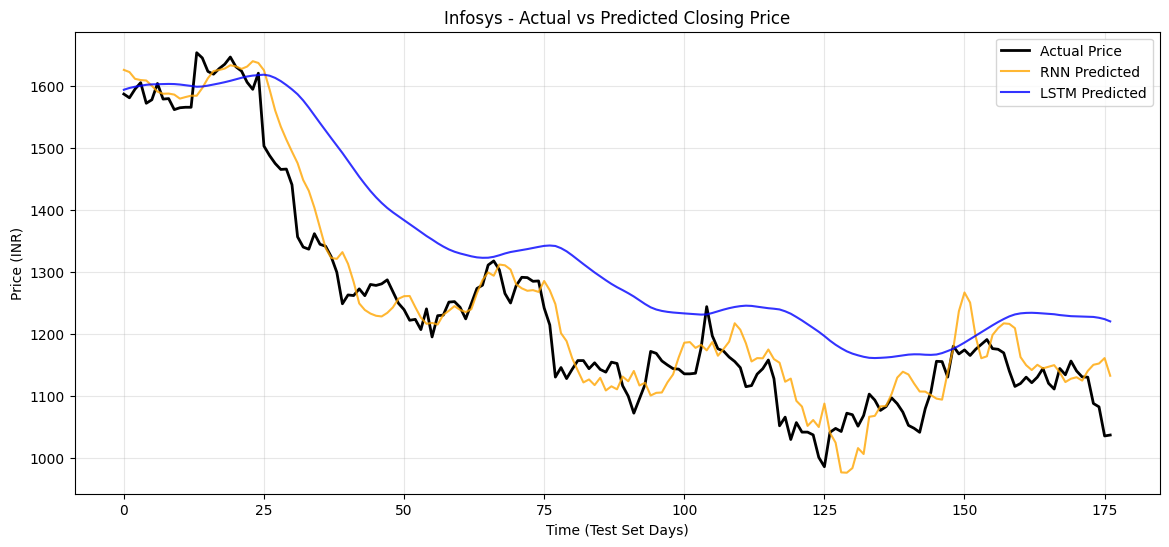

In [33]:
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual Price", color="black", linewidth=2)
plt.plot(rnn_preds, label="RNN Predicted", color="orange", alpha=0.8)
plt.plot(lstm_preds, label="LSTM Predicted", color="blue", alpha=0.8)
plt.title(f"{TICKER_NAME} - Actual vs Predicted Closing Price")
plt.xlabel("Time (Test Set Days)")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Step 10: Real-Time Simulation — Predict the Next Closing Price

This is the "real-time" part of my project. I:
1. Pull the **latest available data** (last `WINDOW_SIZE` days, up to today)
2. Feed it into the trained model
3. Predict tomorrow's likely closing price



In [34]:
latest_data = yf.download(TICKER, period="90d", interval="1d")[["Close"]].dropna()

last_window = latest_data["Close"].values[-WINDOW_SIZE:]
last_window_scaled = scaler.transform(last_window.reshape(-1, 1))
last_window_scaled = last_window_scaled.reshape(1, WINDOW_SIZE, 1)

next_day_pred_scaled = lstm_model.predict(last_window_scaled)
next_day_pred = scaler.inverse_transform(next_day_pred_scaled)

print(f"Latest actual close ({latest_data.index[-1].date()}): {latest_data['Close'].values[-1].item():.2f}")
print(f"Predicted next closing price: {next_day_pred[0][0]:.2f}")

[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Latest actual close (2026-09-10): 1036.50
Predicted next closing price: 1215.41


## Step 11: Save the Model

Save the trained model so you can load it later without retraining — useful if you later build a Streamlit dashboard or deploy it.


In [35]:
lstm_model.save("it_stock_lstm_model.h5")
print("Model saved as it_stock_lstm_model.h5")


Model saved as it_stock_lstm_model.h5


# Step 12: Market Cap Fetch & Classification


In [36]:
# Step 12: Market Cap Fetch & Classification
# Ek stock dareek category (Large / Mid / Small) mathi lai ne compare karsu

MULTI_SCALE_STOCKS = {
    "Infosys (Large Cap)": "INFY.NS",
    "Persistent Systems (Mid Cap)": "PERSISTENT.NS",
    "Zensar Technologies (Small Cap)": "ZENSARTECH.NS"
}

def get_market_cap_info(ticker_symbol):
    """Fetch market cap and classify into Large / Mid / Small cap (India norms)"""
    stock = yf.Ticker(ticker_symbol)
    info = stock.info
    market_cap = info.get("marketCap", None)

    if market_cap is None:
        return None, "Unknown"

    market_cap_cr = market_cap / 1e7  # convert to INR Crores

    if market_cap_cr > 20000:
        category = "Large Cap"
    elif market_cap_cr > 5000:
        category = "Mid Cap"
    else:
        category = "Small Cap"

    return market_cap_cr, category

print(f"{'Company':<35}{'Market Cap (Cr)':>18}{'Category':>15}")
print("-" * 68)
for name, ticker in MULTI_SCALE_STOCKS.items():
    cap, category = get_market_cap_info(ticker)
    cap_display = f"{cap:,.0f}" if cap else "N/A"
    print(f"{name:<35}{cap_display:>18}{category:>15}")

Company                               Market Cap (Cr)       Category
--------------------------------------------------------------------
Infosys (Large Cap)                           419,814      Large Cap
Persistent Systems (Mid Cap)                   86,075      Large Cap
Zensar Technologies (Small Cap)                 9,693        Mid Cap


# Step 13: Scale for all Reusable Training Function

In [37]:
# Step 13: Reusable pipeline function — data fetch se evaluate sudhi

def run_stock_prediction(ticker_symbol, window_size=60, epochs=30):
    """Fetch data, train an LSTM, and return RMSE/MAE for a given stock"""

    # 1. Fetch 5 years historical data
    stock_df = yf.download(ticker_symbol, period="5y", interval="1d")[["Close"]].dropna()

    if len(stock_df) < window_size + 50:
        print(f"Not enough data for {ticker_symbol}, skipping.")
        return None

    # 2. Scale
    local_scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = local_scaler.fit_transform(stock_df[["Close"]])

    # 3. Sequences
    X_local, y_local = create_sequences(scaled, window_size)
    X_local = X_local.reshape((X_local.shape[0], X_local.shape[1], 1))

    # 4. Time-based split
    split_idx = int(len(X_local) * 0.85)
    X_tr, X_te = X_local[:split_idx], X_local[split_idx:]
    y_tr, y_te = y_local[:split_idx], y_local[split_idx:]

    # 5. Build & train LSTM
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_tr.shape[1], 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model.fit(X_tr, y_tr, validation_split=0.1, epochs=epochs,
              batch_size=32, callbacks=[es], verbose=0)

    # 6. Evaluate
    preds = model.predict(X_te, verbose=0)
    preds_actual = local_scaler.inverse_transform(preds)
    y_te_actual = local_scaler.inverse_transform(y_te.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_te_actual, preds_actual))
    mae = mean_absolute_error(y_te_actual, preds_actual)

    # Also compute % volatility (daily returns std dev) — shows how "jumpy" the stock is
    daily_returns = stock_df["Close"].pct_change().dropna()
    volatility_pct = daily_returns.std() * 100

    return {
        "rmse": rmse,
        "mae": mae,
        "volatility_pct": volatility_pct,
        "y_actual": y_te_actual,
        "preds": preds_actual
    }

#Step 14: Teen Category Par Train & Compare Karo


In [38]:
results = {}

for name, ticker in MULTI_SCALE_STOCKS.items():
    print(f"\nTraining model for {name} ({ticker}) ...")
    result = run_stock_prediction(ticker)
    if result:
        results[name] = result
        print(f"  RMSE: {result['rmse']:.2f} | MAE: {result['mae']:.2f} | Volatility: {result['volatility_pct'].item():.2f}%")


Training model for Infosys (Large Cap) (INFY.NS) ...


[*********************100%***********************]  1 of 1 completed


  RMSE: 52.46 | MAE: 40.69 | Volatility: 1.63%

Training model for Persistent Systems (Mid Cap) (PERSISTENT.NS) ...


[*********************100%***********************]  1 of 1 completed


  RMSE: 263.65 | MAE: 200.89 | Volatility: 2.21%

Training model for Zensar Technologies (Small Cap) (ZENSARTECH.NS) ...


[*********************100%***********************]  1 of 1 completed


  RMSE: 32.63 | MAE: 27.41 | Volatility: 2.60%


In [39]:
# Comparison table
comparison_df = pd.DataFrame({
    "Company": list(results.keys()),
    "RMSE": [r["rmse"] for r in results.values()],
    "MAE": [r["mae"] for r in results.values()],
    "Volatility (%)": [r["volatility_pct"] for r in results.values()]
})
comparison_df

,Company,RMSE,MAE,Volatility (%)
0,Infosys (Large Cap),52.456261,40.685945,Ticker INFY.NS 1.634854 dtype: float64
1,Persistent Systems (Mid Cap),263.653578,200.894959,Ticker PERSISTENT.NS 2.205366 dtype: float64
2,Zensar Technologies (Small Cap),32.627620,27.414127,Ticker ZENSARTECH.NS 2.59969 dtype: float64


#Step 15: Visualize — Scale-wise Comparison

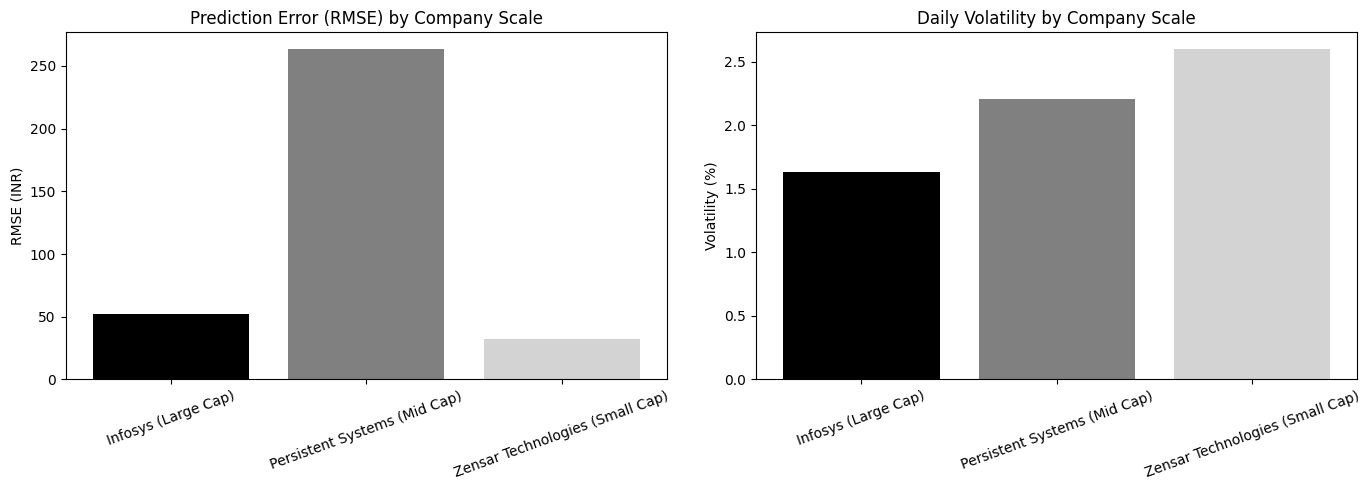


Insight: Large-cap stocks generally show lower volatility and more predictable
patterns (lower RMSE), while small-cap stocks tend to be more volatile and harder to predict.


In [40]:
# Step 15: Bar chart comparing RMSE and Volatility across scales

comparison_df["Volatility (%)"] = comparison_df["Volatility (%)"].apply(lambda x: x.item())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison_df["Company"], comparison_df["RMSE"], color=["black", "gray", "lightgray"])
axes[0].set_title("Prediction Error (RMSE) by Company Scale")
axes[0].set_ylabel("RMSE (INR)")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comparison_df["Company"], comparison_df["Volatility (%)"], color=["black", "gray", "lightgray"])
axes[1].set_title("Daily Volatility by Company Scale")
axes[1].set_ylabel("Volatility (%)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nInsight: Large-cap stocks generally show lower volatility and more predictable")
print("patterns (lower RMSE), while small-cap stocks tend to be more volatile and harder to predict.")

# Step 16: Multiple Features sathe Data Fetch

In [41]:
# Step 16: Multivariate data — Close, Volume, Open, High, Low + technical indicators

def fetch_multivariate_data(ticker_symbol, period="5y"):
    df = yf.download(ticker_symbol, period=period, interval="1d")
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

    # Moving Averages
    df["MA_50"] = df["Close"].rolling(window=50).mean()
    df["MA_200"] = df["Close"].rolling(window=200).mean()

    # RSI (Relative Strength Index) — manual calculation, no extra library needed
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
    rs = gain / loss
    df["RSI"] = 100 - (100 / (1 + rs))

    df.dropna(inplace=True)  # drop initial NaN rows from rolling windows
    return df

multi_df = fetch_multivariate_data(TICKER)
print(f"Shape: {multi_df.shape}")
multi_df.tail()

[*********************100%***********************]  1 of 1 completed

Shape: (1041, 8)


Price,Open,High,Low,Close,Volume,MA_50,MA_200,RSI
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,,,
Date,,,,,,,,
2026-09-04,1133.000000,1146.699951,1125.400024,1130.0,5881388,1110.204000,1286.435960,47.483469
2026-09-07,1109.500000,1109.900024,1085.000000,1087.5,7668346,1111.220001,1284.353684,43.583755
2026-09-08,1095.000000,1095.000000,1078.900024,1082.0,6269037,1112.852001,1282.202307,41.209281
2026-09-09,1059.000000,1059.000000,1026.500000,1035.0,13530457,1113.846001,1279.801248,31.135807
2026-09-10,1039.599976,1046.599976,1027.300049,1036.5,8997421,1113.758000,1277.492847,32.705676


# Step 17: Multivariate Scaling & Sequence Creation

In [42]:
# Step 17: Scale ALL features, but predict only Close

FEATURES = ["Open", "High", "Low", "Close", "Volume", "MA_50", "MA_200", "RSI"]
TARGET_COL_INDEX = FEATURES.index("Close")

multi_scaler = MinMaxScaler(feature_range=(0, 1))
multi_scaled = multi_scaler.fit_transform(multi_df[FEATURES])

def create_multivariate_sequences(data, window_size, target_idx):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])          # all features for the window
        y.append(data[i, target_idx])                 # only Close price as target
    return np.array(X), np.array(y)

X_multi, y_multi = create_multivariate_sequences(multi_scaled, WINDOW_SIZE, TARGET_COL_INDEX)
print("X_multi shape:", X_multi.shape)   # (samples, timesteps, num_features)
print("y_multi shape:", y_multi.shape)

X_multi shape: (981, 60, 8)
y_multi shape: (981,)


# Step 18: Multivariate LSTM Train & Evaluate

In [43]:
# Step 18: Train LSTM on multiple features

split_idx_m = int(len(X_multi) * 0.85)
X_tr_m, X_te_m = X_multi[:split_idx_m], X_multi[split_idx_m:]
y_tr_m, y_te_m = y_multi[:split_idx_m], y_multi[split_idx_m:]

multi_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_tr_m.shape[1], X_tr_m.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
multi_model.compile(optimizer="adam", loss="mean_squared_error")

multi_model.fit(X_tr_m, y_tr_m, validation_split=0.1, epochs=40,
                batch_size=32, callbacks=[early_stop], verbose=1)

# Evaluate — inverse transform needs a trick since scaler was fit on all features
preds_scaled = multi_model.predict(X_te_m)

# Build dummy array to inverse-transform just the Close column correctly
dummy = np.zeros((len(preds_scaled), len(FEATURES)))
dummy[:, TARGET_COL_INDEX] = preds_scaled.flatten()
preds_actual_multi = multi_scaler.inverse_transform(dummy)[:, TARGET_COL_INDEX]

dummy_y = np.zeros((len(y_te_m), len(FEATURES)))
dummy_y[:, TARGET_COL_INDEX] = y_te_m
y_te_actual_multi = multi_scaler.inverse_transform(dummy_y)[:, TARGET_COL_INDEX]

rmse_multi = np.sqrt(mean_squared_error(y_te_actual_multi, preds_actual_multi))
mae_multi = mean_absolute_error(y_te_actual_multi, preds_actual_multi)

print(f"Multivariate LSTM — RMSE: {rmse_multi:.2f} | MAE: {mae_multi:.2f}")
print(f"(Compare to single-feature LSTM RMSE: {lstm_rmse:.2f})")

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0674 - val_loss: 0.0026
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0109 - val_loss: 0.0026
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0067 - val_loss: 0.0060
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0060 - val_loss: 0.0051
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0052 - val_loss: 0.0059
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Multivariate LSTM — RMSE: 132.26 | MAE: 120.63
(Compare to single-feature LSTM RMSE: 118.24)


# Step 19: Save Multivariate Model + Scaler (Streamlit mate jarur padse)

In [44]:
# Step 19: Save everything needed for deployment
import joblib

multi_model.save("it_stock_multivariate_lstm.h5")
joblib.dump(multi_scaler, "multi_scaler.pkl")
joblib.dump(FEATURES, "feature_list.pkl")

print("Model, scaler, and feature list saved — ready for Streamlit app")

Model, scaler, and feature list saved — ready for Streamlit app


# Step 20: News fetching + sentiment analysis libraries



In [45]:
!pip install feedparser vaderSentiment --quiet

import feedparser
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime, timedelta

print("News sentiment libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00
News sentiment libraries loaded


# Step 21: Fetch recent news headlines for the selected stock — no API key needed


In [46]:

def fetch_news_headlines(company_name, max_articles=30):
    """Pulls recent news headlines from Google News RSS for a given company."""
    query = company_name.replace(" ", "+")
    url = f"https://news.google.com/rss/search?q={query}+stock&hl=en-IN&gl=IN&ceid=IN:en"

    feed = feedparser.parse(url)
    articles = []

    for entry in feed.entries[:max_articles]:
        articles.append({
            "title": entry.title,
            "published": entry.get("published", "Unknown"),
        })

    return pd.DataFrame(articles)

# Example: fetch news for the stock you're analyzing
COMPANY_SEARCH_NAME = "Infosys"   # change this to match TICKER_NAME
news_df = fetch_news_headlines(COMPANY_SEARCH_NAME)
print(f"Fetched {len(news_df)} recent headlines")
news_df.head(10)

Fetched 30 recent headlines


,title,published
0,"Infosys shares slump over 4.5%, post biggest s...","Wed, 09 Sep 2026 08:57:25 GMT"
1,Infosys shares extend losing streak to sixth s...,"Wed, 09 Sep 2026 09:58:43 GMT"
2,"Infosys, HCLTech, Coforge tumble up to 6%: Why...","Wed, 09 Sep 2026 04:15:18 GMT"
3,"Nifty IT falls over 1%; Infosys, Tech Mahindra...","Mon, 07 Sep 2026 03:59:09 GMT"
4,"Infosys Hits ₹1,026.50 Low as IT Stocks Slide ...","Wed, 09 Sep 2026 11:32:00 GMT"
5,Infosys shares extend losing streak to sixth s...,"Wed, 09 Sep 2026 09:37:13 GMT"
6,Infosys Share Price Update: Price Action and P...,"Mon, 07 Sep 2026 04:11:00 GMT"
7,Why Infosys Share Price is Falling - Equitymaster,"Mon, 07 Sep 2026 10:26:14 GMT"
8,"Infosys, TCS, Coforge, Mphasis shares: Targets...","Wed, 09 Sep 2026 05:24:10 GMT"
9,"Infosys, HCLTech, TCS, other IT stocks drop up...","Mon, 07 Sep 2026 06:02:21 GMT"


# Step 22: Run sentiment analysis on each headline


In [47]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    """Returns a compound sentiment score between -1 (very negative) and +1 (very positive)."""
    scores = analyzer.polarity_scores(text)
    return scores["compound"]

news_df["sentiment_score"] = news_df["title"].apply(get_sentiment_score)

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

news_df["sentiment_label"] = news_df["sentiment_score"].apply(classify_sentiment)

print(news_df[["title", "sentiment_score", "sentiment_label"]].to_string(index=False))

                                                                                                                      title  sentiment_score sentiment_label
                               Infosys shares slump over 4.5%, post biggest single day fall in nearly three months - Upstox           0.2960        Positive
   Infosys shares extend losing streak to sixth straight session, losing ₹40,000 crore in market cap - CNBC TV18 - LinkedIn          -0.1027        Negative
                                     Infosys, HCLTech, Coforge tumble up to 6%: Why are IT stocks down today? - India Today           0.0000         Neutral
         Nifty IT falls over 1%; Infosys, Tech Mahindra, HCL Tech lead losses as Fed rate hike bets rise - Moneycontrol.com           0.0000         Neutral
                                                       Infosys Hits ₹1,026.50 Low as IT Stocks Slide 6th Day - Equitypandit          -0.2732        Negative
              Infosys shares extend losing streak to sixth

# Step 23: Aggregate sentiment and visualize the split


Average news sentiment score for Infosys: 0.112

Sentiment breakdown:
sentiment_label
Positive    15
Negative     8
Neutral      7
Name: count, dtype: int64


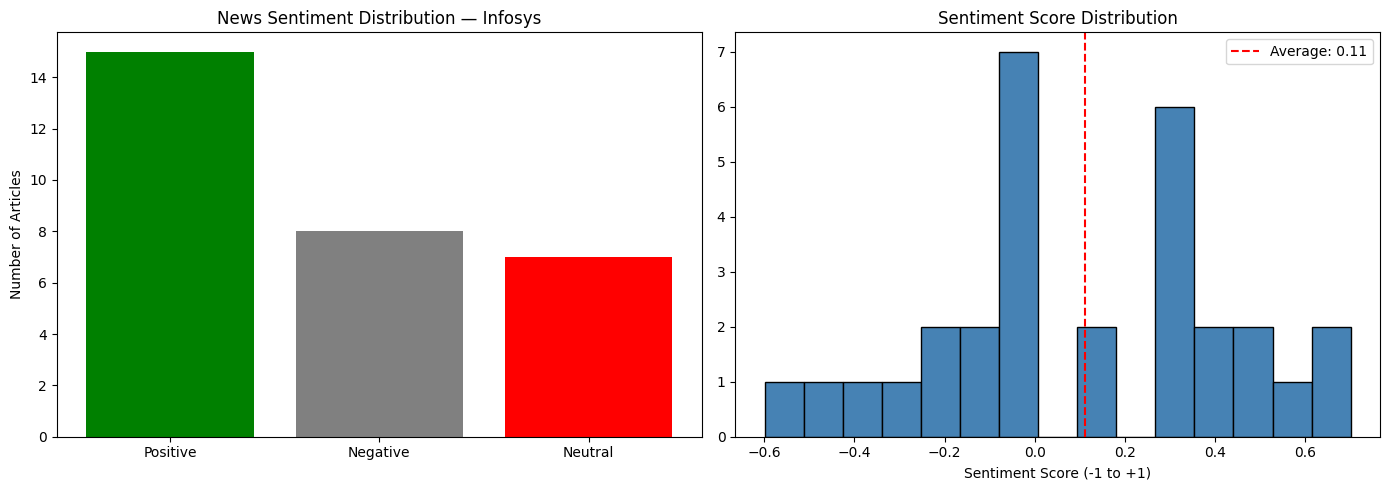

In [48]:

avg_sentiment = news_df["sentiment_score"].mean()
sentiment_counts = news_df["sentiment_label"].value_counts()

print(f"Average news sentiment score for {COMPANY_SEARCH_NAME}: {avg_sentiment:.3f}")
print(f"\nSentiment breakdown:\n{sentiment_counts}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: sentiment distribution
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=["green", "gray", "red"])
axes[0].set_title(f"News Sentiment Distribution — {COMPANY_SEARCH_NAME}")
axes[0].set_ylabel("Number of Articles")

# Score distribution
axes[1].hist(news_df["sentiment_score"], bins=15, color="steelblue", edgecolor="black")
axes[1].axvline(avg_sentiment, color="red", linestyle="--", label=f"Average: {avg_sentiment:.2f}")
axes[1].set_title("Sentiment Score Distribution")
axes[1].set_xlabel("Sentiment Score (-1 to +1)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Step 24: Extended recommendation combining Technical + News Sentiment


In [50]:
def generate_fusion_recommendation(df, pred_price, latest_close, news_sentiment_avg):
    """Combines trend, momentum, model prediction, AND news sentiment into one signal."""
    score = 0
    reasons = []

    ma50 = df["MA_50"].values[-1]
    ma200 = df["MA_200"].values[-1]
    rsi = df["RSI"].values[-1]

    # 1. Trend signal
    if ma50 > ma200:
        score += 1
        reasons.append("Technical trend: 50-day average above 200-day average (uptrend).")
    else:
        score -= 1
        reasons.append("Technical trend: 50-day average below 200-day average (downtrend).")

    # 2. Momentum signal (RSI)
    if rsi > 70:
        score -= 1
        reasons.append(f"Momentum: RSI at {rsi:.1f} — overbought.")
    elif rsi < 30:
        score += 1
        reasons.append(f"Momentum: RSI at {rsi:.1f} — oversold, possible rebound.")
    else:
        reasons.append(f"Momentum: RSI at {rsi:.1f} — neutral.")

    # 3. Model prediction signal
    predicted_change_pct = ((pred_price - latest_close) / latest_close) * 100
    if predicted_change_pct > 0.5:
        score += 1
        reasons.append(f"LSTM model predicts a rise of {predicted_change_pct:.2f}% next session.")
    elif predicted_change_pct < -0.5:
        score -= 1
        reasons.append(f"LSTM model predicts a fall of {predicted_change_pct:.2f}% next session.")
    else:
        reasons.append("LSTM model predicts little price movement.")

    # 4. NEW: News sentiment signal
    if news_sentiment_avg >= 0.15:
        score += 1
        reasons.append(f"News sentiment is positive (avg score {news_sentiment_avg:.2f}) — favorable coverage.")
    elif news_sentiment_avg <= -0.15:
        score -= 1
        reasons.append(f"News sentiment is negative (avg score {news_sentiment_avg:.2f}) — unfavorable coverage.")
    else:
        reasons.append(f"News sentiment is neutral (avg score {news_sentiment_avg:.2f}).")

    if score >= 3:
        label = "Strong Bullish Signal"
    elif score >= 1:
        label = "Bullish Signal"
    elif score <= -3:
        label = "Strong Bearish Signal"
    elif score <= -1:
        label = "Bearish Signal"
    else:
        label = "Neutral / Mixed Signal"

    return label, reasons


# Run it
pred_price = next_day_pred[0][0]
latest_close = latest_data["Close"].values[-1].item()

fusion_label, fusion_reasons = generate_fusion_recommendation(
    multi_df, pred_price, latest_close, avg_sentiment
)

print(f"=== FUSION SIGNAL: {fusion_label} ===\n")
for r in fusion_reasons:
    print(f"- {r}")

print("\nDisclaimer: This is an academic project combining technical indicators")
print("with a rule-based news sentiment score. It is NOT financial advice.")

=== FUSION SIGNAL: Neutral / Mixed Signal ===

- Technical trend: 50-day average below 200-day average (downtrend).
- Momentum: RSI at 32.7 — neutral.
- LSTM model predicts a rise of 17.26% next session.
- News sentiment is neutral (avg score 0.11).

Disclaimer: This is an academic project combining technical indicators
with a rule-based news sentiment score. It is NOT financial advice.
